In [17]:
from __future__ import annotations

import logging
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
from scipy.stats import ttest_rel
from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.ddm.ddm

importlib.reload(src.ddm.ddm)

import numpy as np
import torch
import pickle

from config import dir_config

from src.ddm.utils import build_stimulus, prepare_data, load_model
from src.utils import pmf_utils

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


### config

In [4]:
# change directory to project root
import os

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

from scripts.ddm.ddm_fitting import DDMModel

processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / "ddm"

behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")
metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")

best_model = "leak-1_tc-1"
model_dir = ddm_dir / best_model

## Functions

### sessions categorization

In [5]:
model_files = [load_model(model_path) for model_path in tqdm(model_dir.glob("*.pkl"), unit="file")]

200file [01:35,  2.09file/s]


In [6]:
asm_controls = {}
trem_off_meds, trem_on_meds = {}, {}
brady_off_meds, brady_on_meds = {}, {}

In [7]:
asm_controls["session_ids"] = metadata[metadata["is_pd"] == 0]["session_id"].unique()
trem_off_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "tremor") & (metadata["treatment"] == "OFF")]["session_id"].unique()
trem_on_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "tremor") & (metadata["treatment"] == "ON")]["session_id"].unique()
brady_off_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "bradykinetic") & (metadata["treatment"] == "OFF")]["session_id"].unique()
brady_on_meds["session_ids"] = metadata[(metadata["trem_vs_brady_type"] == "bradykinetic") & (metadata["treatment"] == "ON")]["session_id"].unique()

print(f"ASM healthy controls: {len(asm_controls['session_ids'])}")
print(f"Tremor off meds: {len(trem_off_meds['session_ids'])}")
print(f"Tremor on meds: {len(trem_on_meds['session_ids'])}")
print(f"Bradykinetic off meds: {len(brady_off_meds['session_ids'])}")
print(f"Bradykinetic on meds: {len(brady_on_meds['session_ids'])}")

ASM healthy controls: 18
Tremor off meds: 11
Tremor on meds: 11
Bradykinetic off meds: 10
Bradykinetic on meds: 10


In [8]:
# collect models for each group
asm_controls["models"] = [model for model in model_files if model["job"]["session_id"] in asm_controls["session_ids"]]
trem_off_meds["models"] = [model for model in model_files if model["job"]["session_id"] in trem_off_meds["session_ids"]]
trem_on_meds["models"] = [model for model in model_files if model["job"]["session_id"] in trem_on_meds["session_ids"]]
brady_off_meds["models"] = [model for model in model_files if model["job"]["session_id"] in brady_off_meds["session_ids"]]
brady_on_meds["models"] = [model for model in model_files if model["job"]["session_id"] in brady_on_meds["session_ids"]]

In [23]:
def get_simulated_data(model_struct, behavior_df):
    session_data = prepare_data(
        behavior_df,
        session_id=model_struct["job"]["session_id"],
        color=int(model_struct["job"]["color"]),
    )
    stimulus = build_stimulus(session_data)
    sim_data = model_struct["model"].simulate(stimulus=stimulus, params=model_struct["results"]["parameters"], n_reps=1)
    return session_data, pd.DataFrame(sim_data)


def get_params_sdata_ddata(group_dict:dict):
    fitted_params = []
    agg_sdata = []
    agg_ddata = []
    for model in group_dict["models"]:
        session_id = model["job"]["session_id"]
        color = model["job"]["color"]
        fitted_params.append({
            "session_id": session_id,
            "prior_cond": color,
            **model["results"]["parameters"]
        })
        d_session, s_session = get_simulated_data(model, behavior_df)
        d_session["session_id"] = s_session["session_id"] = session_id
        d_session["prior_cond"] = s_session["prior_cond"] = color
        agg_ddata.append(d_session)
        agg_sdata.append(s_session)

    return pd.DataFrame(fitted_params), pd.concat(agg_sdata, ignore_index=True), pd.concat(agg_ddata, ignore_index=True)


def plot_param_comparison(fitted_params, model_name=""):
    from matplotlib.patches import Patch

    eq_color, uq_color = "gray", "black"

    ignore_cols = ["session_id", "prior_cond", "dt", "variance"]

    equal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_cond"] == 0].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)
    unequal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_cond"] == 1].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)

    param_cols = [c for c in fitted_params.columns if c not in ignore_cols]
    fig, axs = plt.subplots(1, len(param_cols), figsize=(5 * len(param_cols), 8))
    if len(param_cols) == 1:
        axs = [axs]

    for ax_idx, col in enumerate(param_cols):
        t_stat, t_p_value = ttest_rel(equal_block[col], unequal_block[col])
        means = [equal_block[col].mean(), unequal_block[col].mean()]
        sems = [equal_block[col].sem(), unequal_block[col].sem()]

        sns.barplot(x=["Equal Prior", "Unequal Prior"], y=means, yerr=sems, palette=[eq_color, uq_color], ax=axs[ax_idx])
        p_str = f"{t_p_value:.3f}" if not np.isnan(t_p_value) else "n/a"
        axs[ax_idx].set_ylabel(col)
        axs[ax_idx].set_title(f"{col}\np = {p_str}", fontsize=18)
        axs[ax_idx].spines["top"].set_visible(False)
        axs[ax_idx].spines["right"].set_visible(False)

    handles = [Patch(color=eq_color, label="Equal Prior"), Patch(color=uq_color, label="Unequal Prior")]
    axs[-1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False)

    if model_name:
        plt.suptitle(model_name, fontsize=26)
    plt.tight_layout()
    return fig

def plot_ddm_fit(data, sim, title="DDM Fit"):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 7))

    cohs_sorted = sorted(data["signed_coherence"].unique())

    def summarize(df):
        p_upper = []
        mean_rt_upper, sem_rt_upper = [], []
        mean_rt_lower, sem_rt_lower = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            sem_rt_upper.append(upper.sem() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
            sem_rt_lower.append(lower.sem() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(sem_rt_upper), np.array(mean_rt_lower), np.array(sem_rt_lower)

    def get_subset(df, outcome):
        if outcome == "correct":
            return df[((df["choice"] == 1) & (df["signed_coherence"] > 0)) | ((df["choice"] == 0) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)]
        elif outcome == "incorrect":
            return df[((df["choice"] == 0) & (df["signed_coherence"] > 0)) | ((df["choice"] == 1) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)]
        else:
            raise ValueError("Outcome must be 'correct' or 'incorrect'")

    def summarize2(df, outcome):
        df = get_subset(df, outcome)
        mean_rt, sem_rt = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            mean_rt.append(subset["rt"].mean() if len(subset) > 0 else np.nan)
            sem_rt.append(subset["rt"].sem() if len(subset) > 0 else np.nan)
        return np.array(mean_rt), np.array(sem_rt)

    def plot_chromo_sem(x, y, yerr, color, label, ax):
        ax.plot(x, y, "o-", color=color, label=label)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)

    d_p_upper, d_mean_rt_upper, d_sem_rt_upper, d_mean_rt_lower, d_sem_rt_lower = summarize(data)
    s_p_upper, s_mean_rt_upper, s_sem_rt_upper, s_mean_rt_lower, s_sem_rt_lower = summarize(sim)

    # Psychometric function
    ax1.plot(cohs_sorted, d_p_upper, "o-", color="steelblue", label="Data")
    ax1.plot(cohs_sorted, s_p_upper, "-", color="tomato", label="Model")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric Function", ylim=(0, 1))

    d_mean_rt_correct, d_sem_rt_correct = summarize2(data, "correct")
    d_mean_rt_incorrect, d_sem_rt_incorrect = summarize2(data, "incorrect")
    s_mean_rt_correct, s_sem_rt_correct = summarize2(sim, "correct")
    s_mean_rt_incorrect, s_sem_rt_incorrect = summarize2(sim, "incorrect")

    plot_chromo_sem(cohs_sorted, d_mean_rt_correct, d_sem_rt_correct, color="steelblue", label="Data", ax=ax2)
    plot_chromo_sem(cohs_sorted, s_mean_rt_correct, s_sem_rt_correct, color="tomato", label="Model", ax=ax2)
    plot_chromo_sem(cohs_sorted, d_mean_rt_incorrect, d_sem_rt_incorrect, color="steelblue", label="Data", ax=ax3)
    plot_chromo_sem(cohs_sorted, s_mean_rt_incorrect, s_sem_rt_incorrect, color="tomato", label="Model", ax=ax3)

    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Correct Trials")
    ax3.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Incorrect Trials")

    y_min = min(ax2.get_ylim()[0], ax3.get_ylim()[0])
    y_max = max(ax2.get_ylim()[1], ax3.get_ylim()[1])
    ax2.set_ylim(y_min, y_max)
    ax3.set_ylim(y_min, y_max)

    ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    for ax in [ax1, ax2, ax3]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(title)
    plt.tight_layout()
    return fig


def plot_group_fits(d_data, s_data, error_type="quantile"):
    """Psychometric + chronometric for both prior blocks.

    error_type: "quantile" -> median ± 10th/90th percentiles
                "std"      -> mean ± 1 SD
    """
    assert error_type in ("quantile", "std"), "error_type must be 'quantile' or 'std'"

    fig, axs = plt.subplots(2, 3, figsize=(18, 8))

    for row, prior_cond in enumerate([0, 1]):

        block_label = "Equal Block" if prior_cond == 0 else "Unequal Block"

        d = d_data[d_data["prior_cond"] == prior_cond]
        s = s_data[s_data["prior_cond"] == prior_cond]

        if d.empty:
            for ax in axs[row]:
                ax.set_visible(False)
            continue

        cohs = sorted(d["signed_coherence"].unique())

        def p_upper(df):
            return [
                (df[df["signed_coherence"] == c]["choice"] == 1).mean()
                if len(df[df["signed_coherence"] == c]) > 0
                else np.nan
                for c in cohs
            ]

        def chrono(df, correct=True):
            center, lo, hi = [], [], []

            for c in cohs:
                sub = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])

                if correct:
                    sub = sub[
                        ((sub["choice"] == 1) & (sub["signed_coherence"] > 0))
                        | ((sub["choice"] == 0) & (sub["signed_coherence"] < 0))
                        | (sub["signed_coherence"] == 0)
                    ]
                else:
                    sub = sub[
                        ((sub["choice"] == 0) & (sub["signed_coherence"] > 0))
                        | ((sub["choice"] == 1) & (sub["signed_coherence"] < 0))
                        | (sub["signed_coherence"] == 0)
                    ]

                if len(sub) > 0:
                    rt = sub["rt"].values
                    if error_type == "quantile":
                        c_val = np.median(rt)
                        lo.append(np.quantile(rt, 0.10))
                        hi.append(np.quantile(rt, 0.90))
                    else:
                        c_val = rt.mean()
                        sd = rt.std() if len(rt) > 1 else 0.0
                        lo.append(c_val - sd)
                        hi.append(c_val + sd)
                    center.append(c_val)
                else:
                    center.append(np.nan)
                    lo.append(np.nan)
                    hi.append(np.nan)

            return np.array(center), np.array(lo), np.array(hi)

        rt_ylabel = "Median RT (s)" if error_type == "quantile" else "Mean RT (s)"

        ax1, ax2, ax3 = axs[row]

        d_coh, d_p_upper, _, d_x_model, d_y_model = pmf_utils.get_psychometric_data(d)
        s_coh, s_p_upper, _, s_x_model, s_y_model = pmf_utils.get_psychometric_data(s)

        ax1.plot(d_coh, d_p_upper, "o", color="steelblue", label="Data")
        ax1.plot(d_x_model, d_y_model, "-", color="steelblue")
        ax1.plot(s_coh, s_p_upper, "o", color="tomato", label="Model")
        ax1.plot(s_x_model, s_y_model, "-", color="tomato")
        ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
        ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
        ax1.set(
            xlabel="Coherence",
            ylabel="P(upper boundary)",
            title=f"{block_label} — Psychometric",
            ylim=(0, 1),
        )



        for ax, correct in [(ax2, True), (ax3, False)]:
            d_ctr, d_lo, d_hi = chrono(d, correct)
            s_ctr, s_lo, s_hi = chrono(s, correct)

            ax.plot(cohs, d_ctr, "o-", color="steelblue", label="Data")
            ax.fill_between(cohs, d_lo, d_hi, color="steelblue", alpha=0.20)

            ax.plot(cohs, s_ctr, "o-", color="tomato", label="Model")
            ax.fill_between(cohs, s_lo, s_hi, color="tomato", alpha=0.20)

            ax.set(
                xlabel="Coherence",
                ylabel=rt_ylabel,
                title=f"{block_label} — Chronometric ({'Correct' if correct else 'Incorrect'})",
            )
            ax.set_ylim(0.25, 1.6)

        ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

        for ax in [ax1, ax2, ax3]:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig

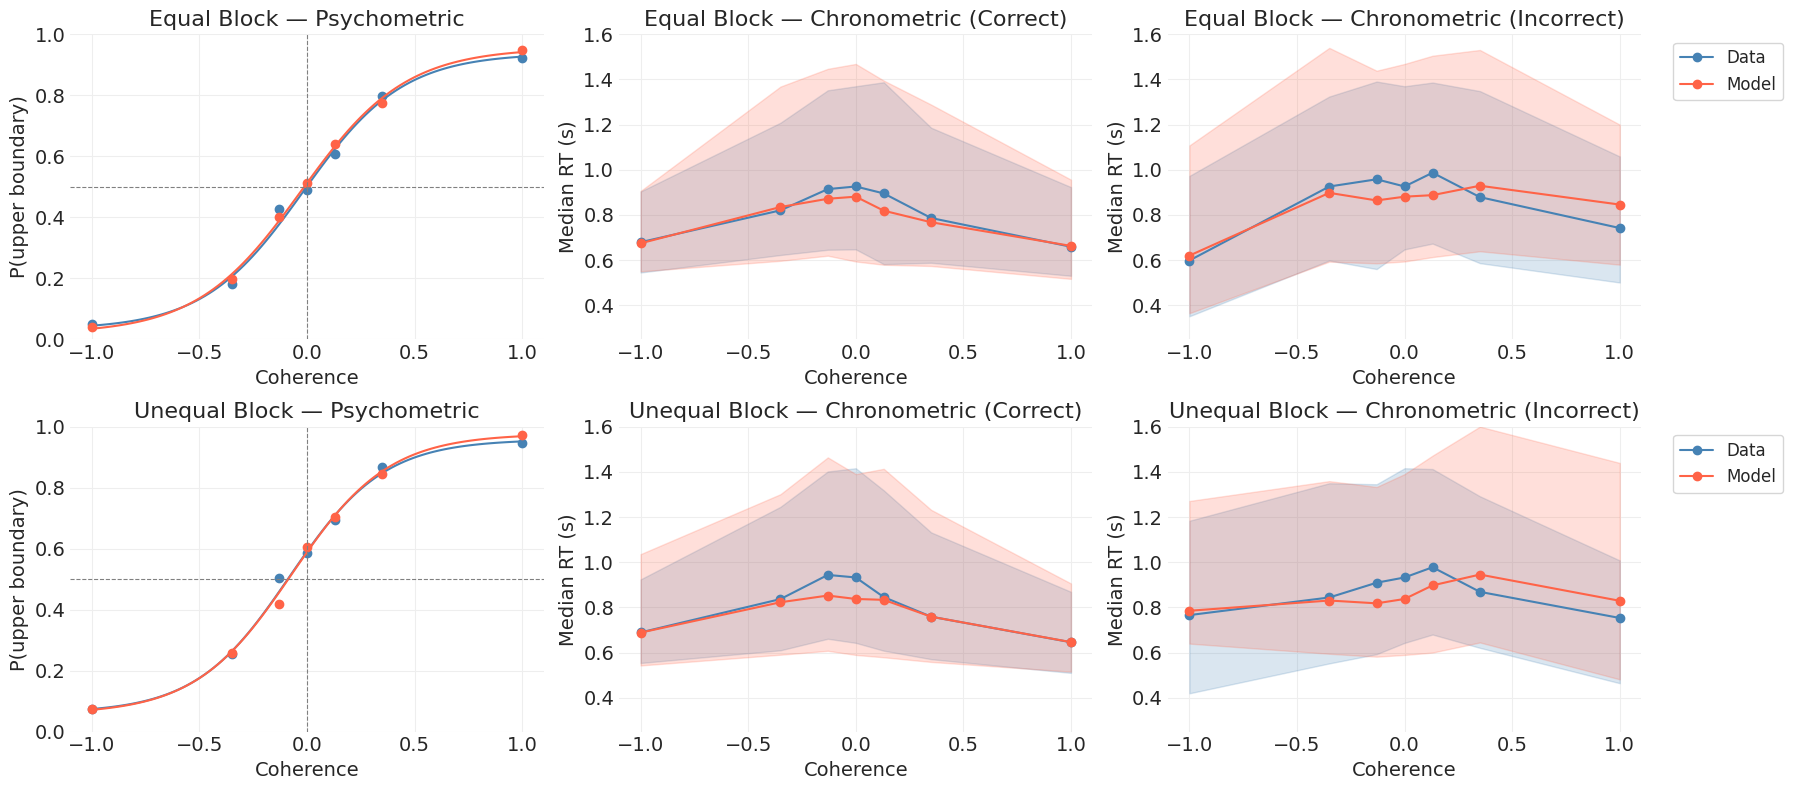

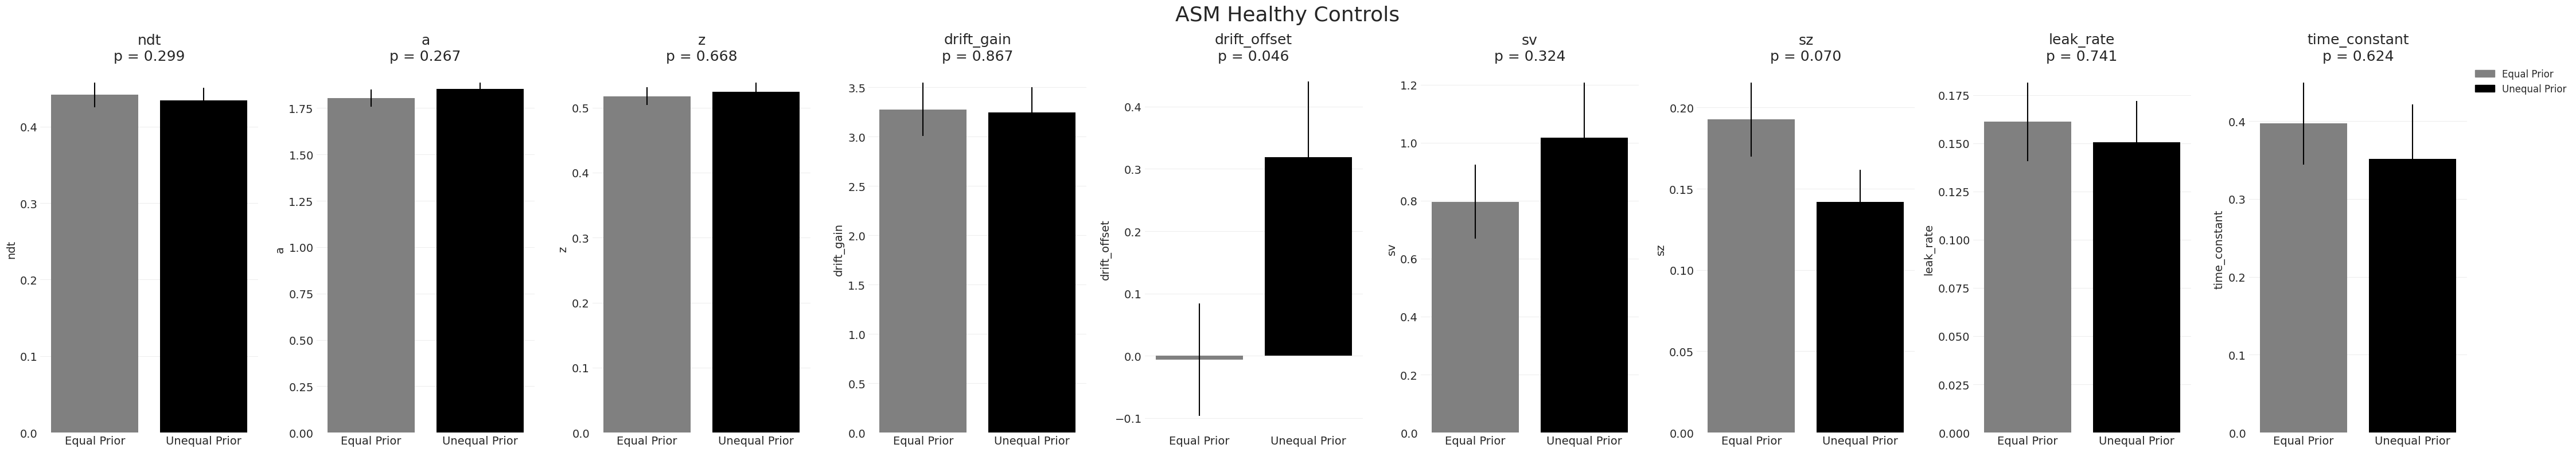

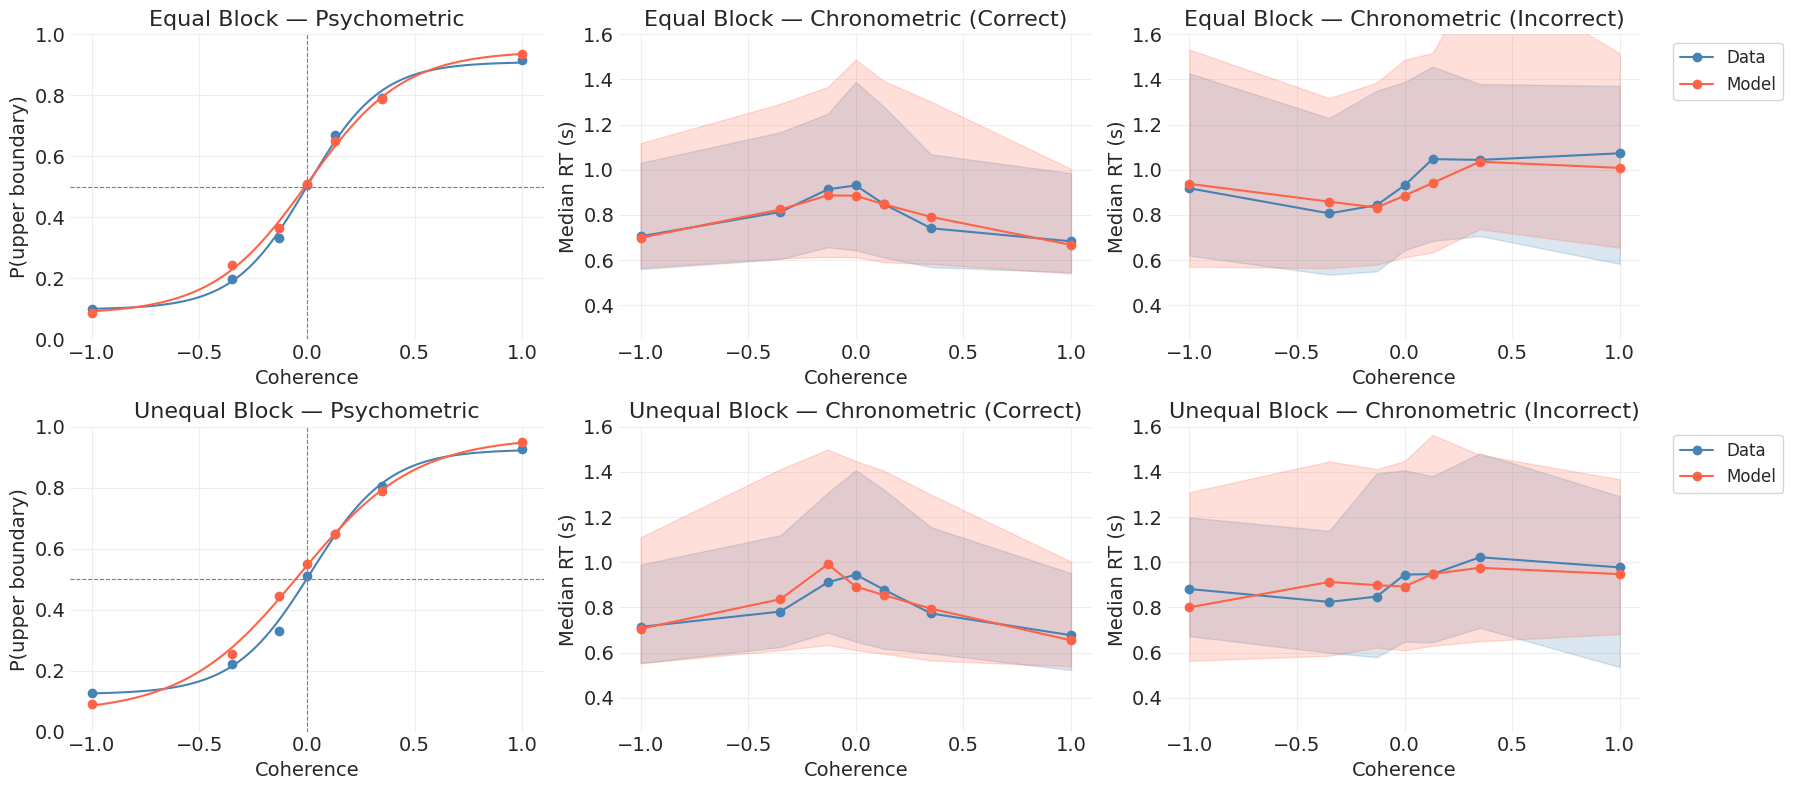

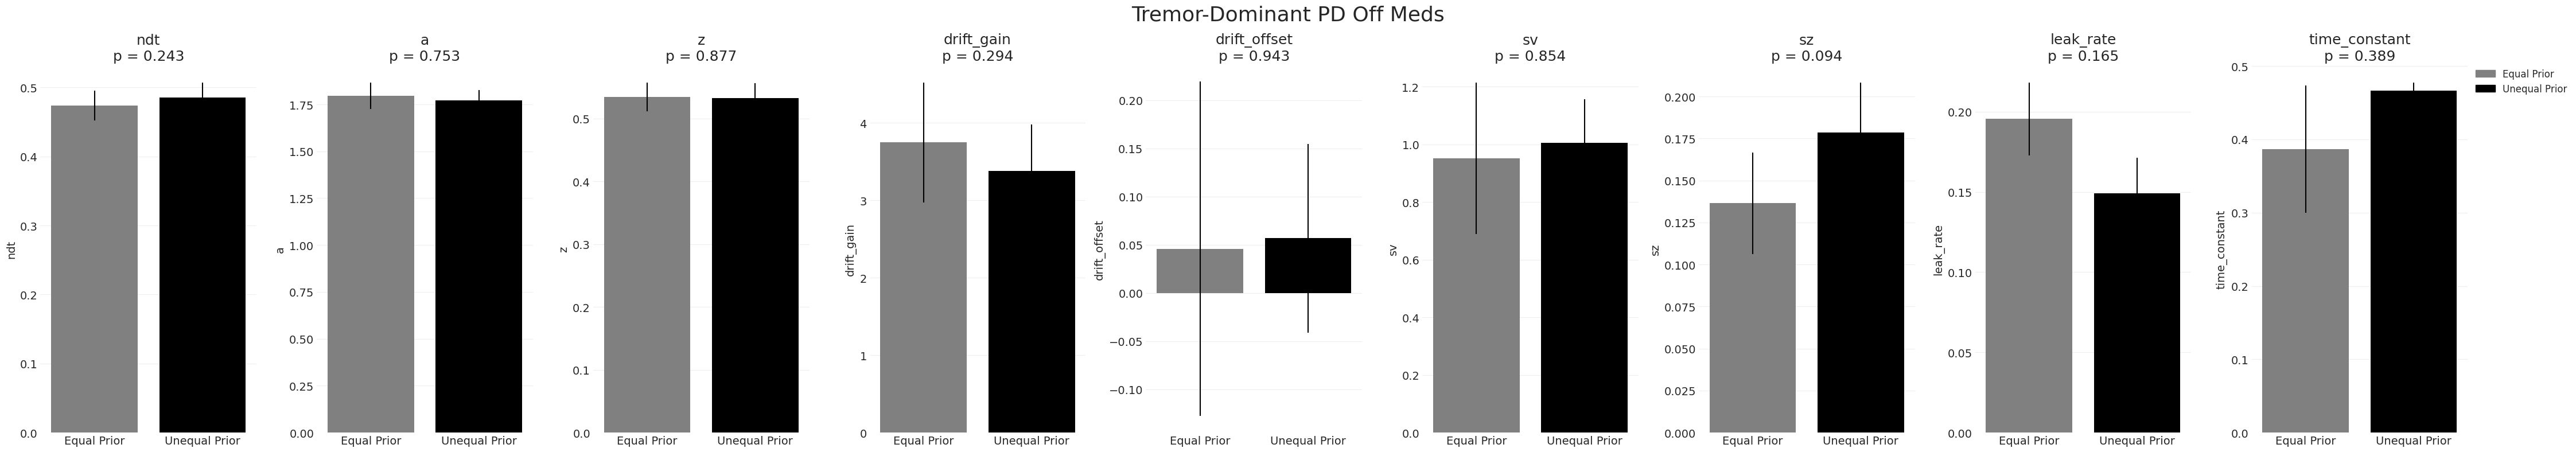

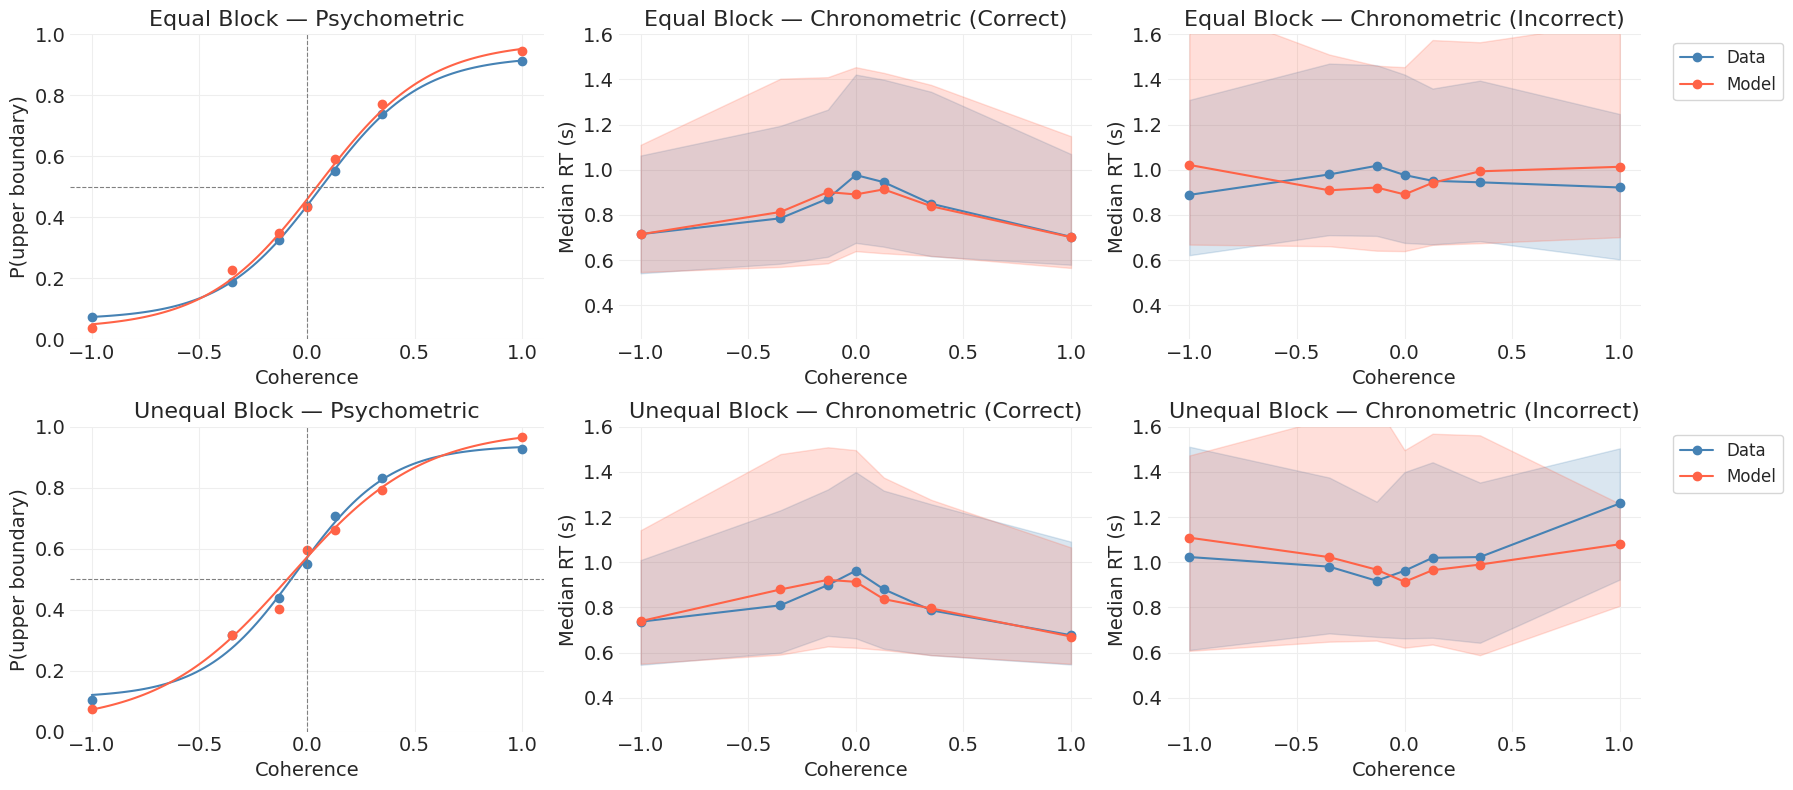

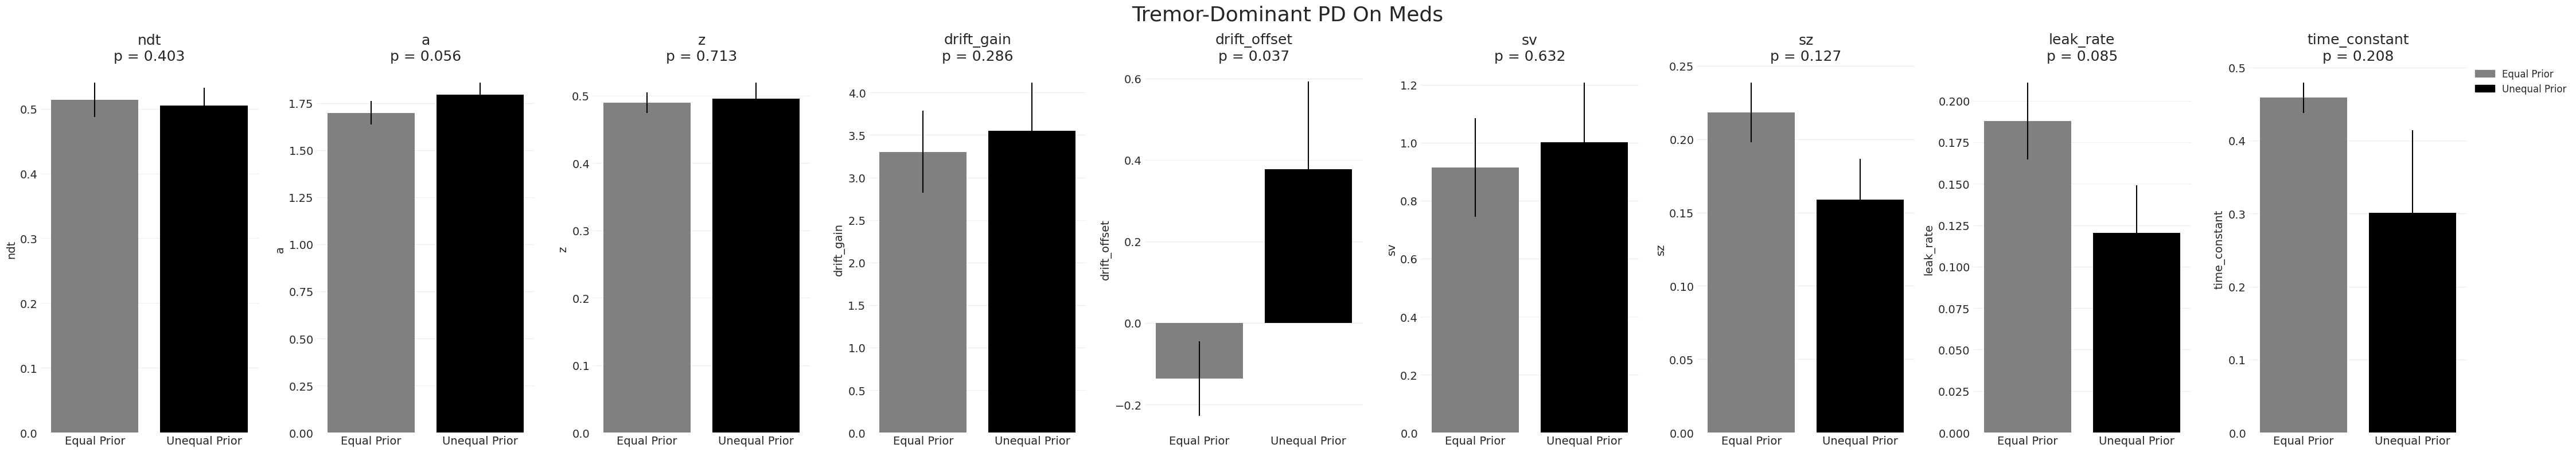

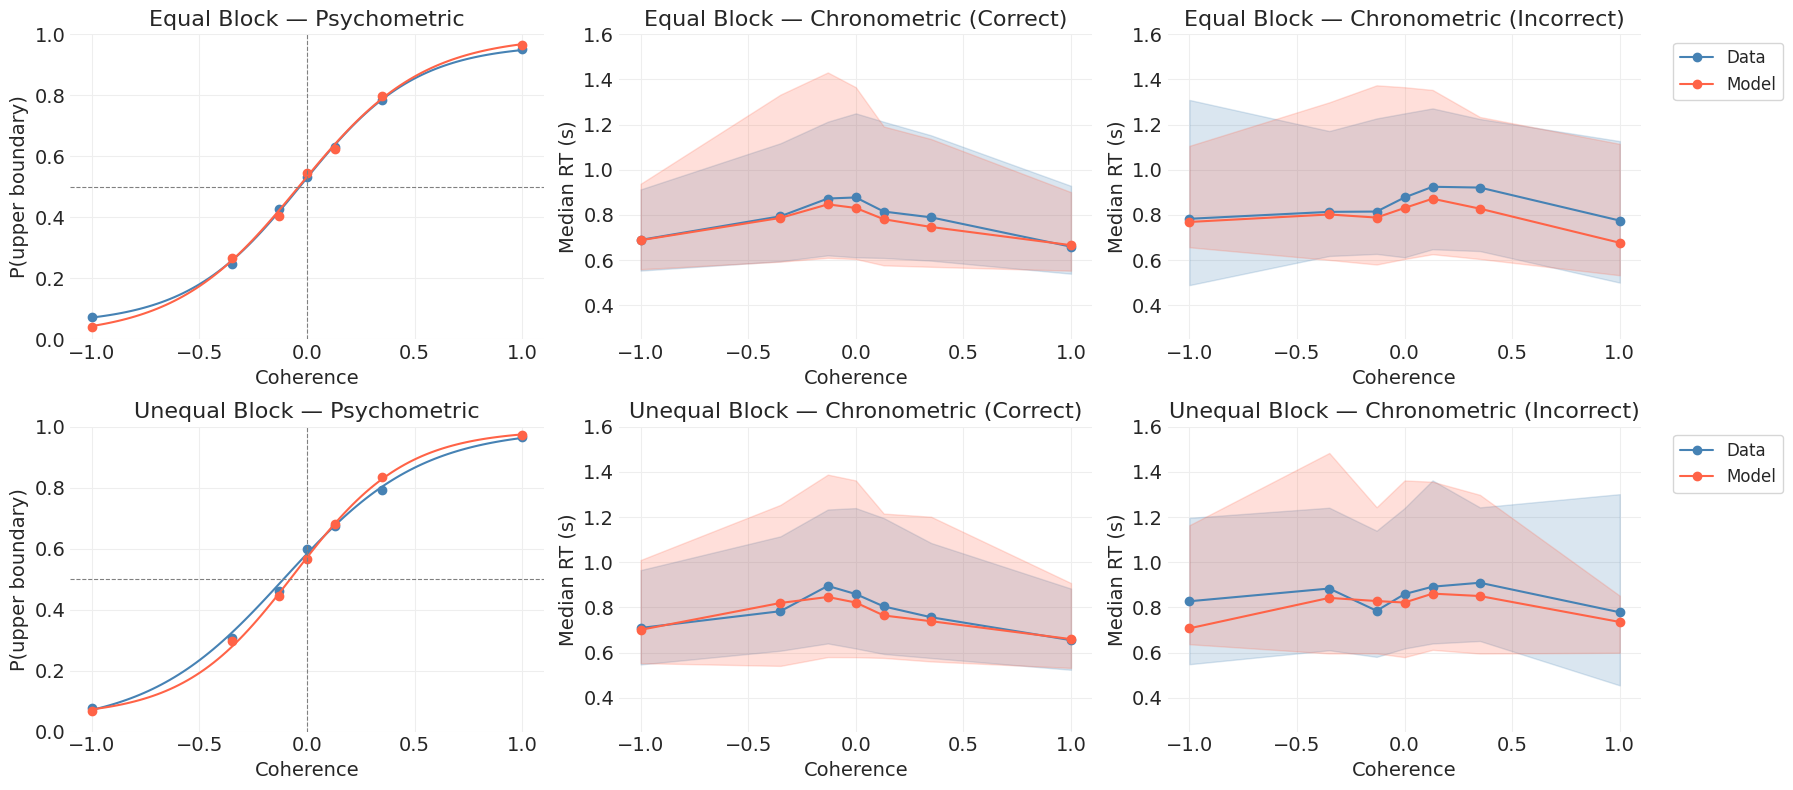

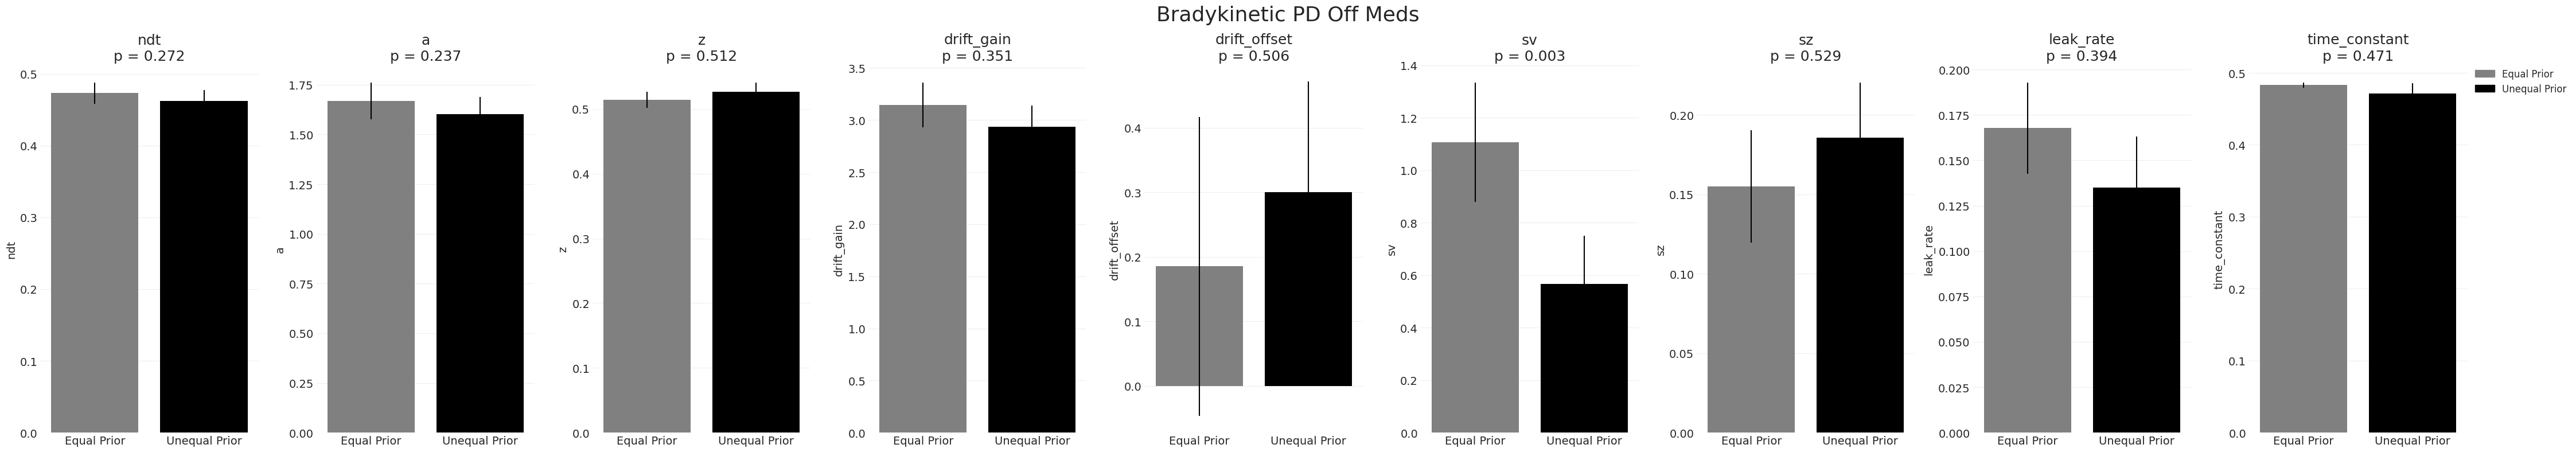

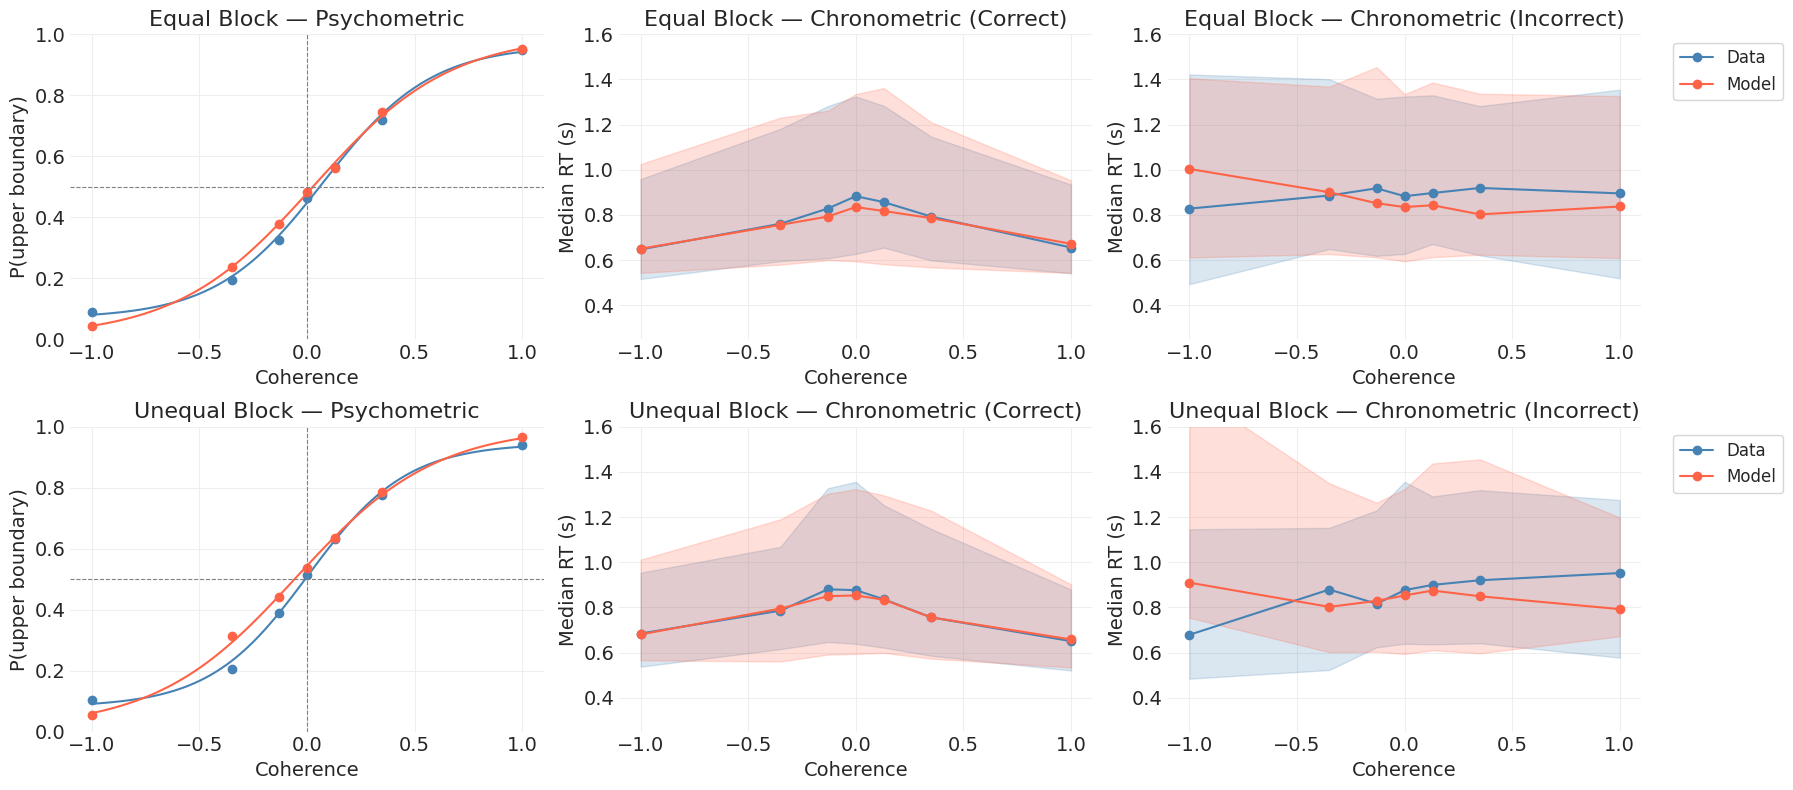

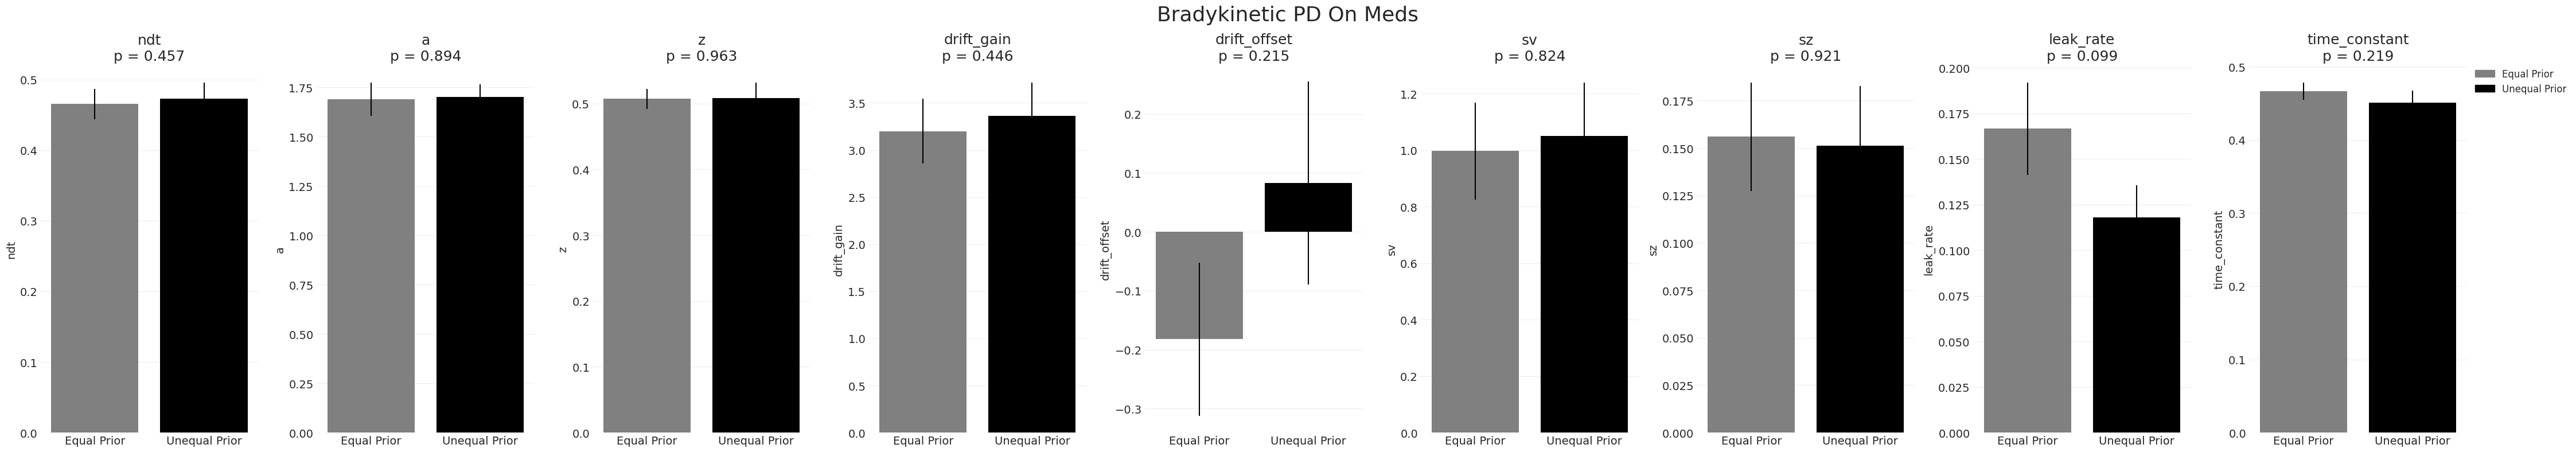

In [25]:
titles = [
    "ASM Healthy Controls",
    "Tremor-Dominant PD Off Meds",
    "Tremor-Dominant PD On Meds",
    "Bradykinetic PD Off Meds",
    "Bradykinetic PD On Meds"
]

figure_dict = {}

for group_dict, title in zip([asm_controls, trem_off_meds, trem_on_meds, brady_off_meds, brady_on_meds], titles):
    params, sdata, ddata = get_params_sdata_ddata(group_dict)
    behav_plot = plot_group_fits(ddata, sdata)
    param_plot = plot_param_comparison(params, model_name=title)
    figure_dict[title] = {"behavior": behav_plot, "parameter": param_plot}


## FINALIZE

In [47]:
params_rows = []
for model in model_files:
    session_id = model["job"]["session_id"]
    color = model["job"]["color"]
    params = model["results"]["parameters"]
    if not model["results"]["optimization_result"]["success"]:
        print(f"Skipping model for session {session_id} with color {color} due to failed optimization")
        continue
    row = {"session_id": session_id}
    row.update({f"{key}_prior_cond_{color}": value for key, value in params.items()})
    params_rows.append(row)


params_df = (
    pd.DataFrame(params_rows)
    .groupby("session_id", as_index=False)
    .first()
)

merged_df = metadata.merge(params_df, on="session_id", how="inner")

missing = set(metadata["session_id"]) - set(merged_df["session_id"])
if missing:
    raise ValueError(f"Missing params for {len(missing)} sessions: {missing}")

merged_df.to_csv(processed_dir / "processed_metadata_all_data_accu_60_ddm_params.csv", index=False)

In [48]:
# save figure_dict to power point with for each group: first slide group name, second slide behavior plot, third slide parameter plot
from pptx import Presentation
from pptx.util import Inches

def save_figures_to_ppt(figure_dict, ppt_path):
    prs = Presentation()
    for group_name, figs in figure_dict.items():
        # Add title slide
        title_slide_layout = prs.slide_layouts[0]
        slide = prs.slides.add_slide(title_slide_layout)
        title = slide.shapes.title
        title.text = group_name

        # Add behavior plot slide
        behav_slide_layout = prs.slide_layouts[5]  # Title Only layout
        slide = prs.slides.add_slide(behav_slide_layout)
        title = slide.shapes.title
        title.text = f"{group_name} - Behavior Fit"
        fig_path = f"{group_name}_behavior.png"
        figs["behavior"].savefig(fig_path, bbox_inches="tight")
        left = Inches(1)
        top = Inches(1.5)
        pic = slide.shapes.add_picture(fig_path, left, top, width=Inches(8))
        # remove the temporary figure file
        os.remove(fig_path)

        # Add parameter plot slide
        param_slide_layout = prs.slide_layouts[5]  # Title Only layout
        slide = prs.slides.add_slide(param_slide_layout)
        title = slide.shapes.title
        title.text = f"{group_name} - Parameter Comparison"
        fig_path = f"{group_name}_parameters.png"
        figs["parameter"].savefig(fig_path, bbox_inches="tight")
        left = Inches(1)
        top = Inches(1.5)
        pic = slide.shapes.add_picture(fig_path, left, top, width=Inches(8))
        # remove the temporary figure file
        os.remove(fig_path)

    prs.save(ppt_path)

save_figures_to_ppt(figure_dict, "dissemination/ddm/ddm_group_comparison.pptx")
